In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score

In [3]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

In [4]:
import pathlib

data_dir = tf.keras.utils.get_file(
    'flower_photos',
    origin=dataset_url,
    untar=True
)

data_dir = pathlib.Path(data_dir)
if (data_dir / 'flower_photos').exists():
    data_dir = data_dir / 'flower_photos'

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
img_height = 224
img_width = 224
batch_size = 32

In [6]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [7]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [8]:
class_names = train_ds.class_names

print(class_names)
print("Number of classes:", len(class_names))

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of classes: 5


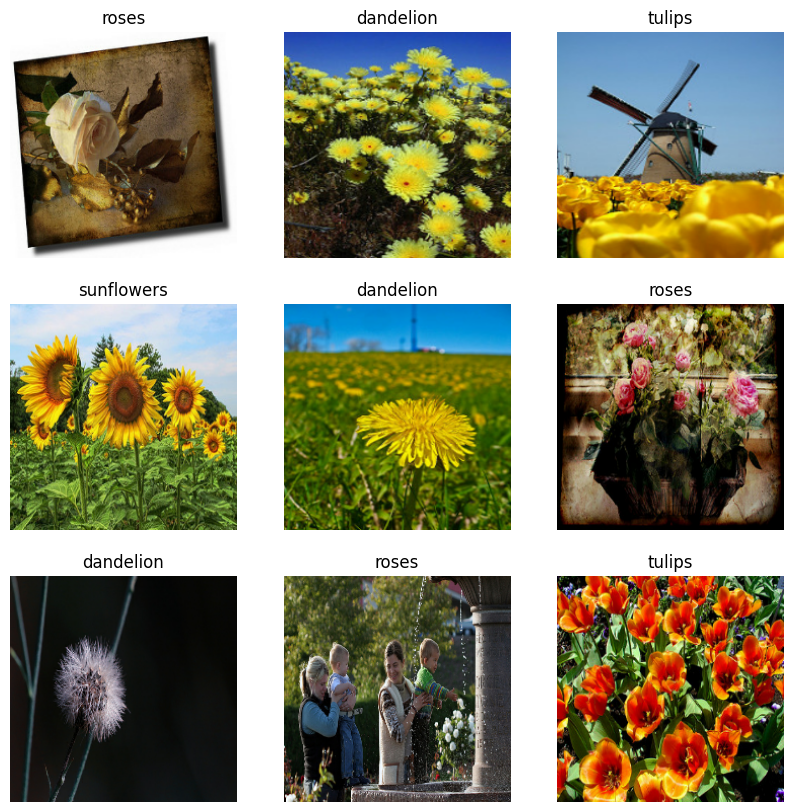

In [9]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [10]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
])

In [12]:
# Using EfficientNetV2B2 instead of MobileNetV2 — much higher accuracy
# include_preprocessing=True means no Rescaling layer needed
base_model = tf.keras.applications.EfficientNetV2B2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True
)

35839040/35839040 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
# PHASE 1 — freeze the base, train only the new head
base_model.trainable = False

In [14]:
model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(len(class_names), activation='softmax')
])

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
# Phase 1 — train the head for 10 epochs
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 39s 193ms/step - accuracy: 0.7503 - loss: 0.7862 - val_accuracy: 0.9005 - val_loss: 0.3157
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 102ms/step - accuracy: 0.8457 - loss: 0.4535 - val_accuracy: 0.9169 - val_loss: 0.2295
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.8665 - loss: 0.3982 - val_accuracy: 0.9292 - val_loss: 0.2220
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.8784 - loss: 0.3251 - val_accuracy: 0.9210 - val_loss: 0.2315
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.8951 - loss: 0.3046 - val_accuracy: 0.9183 - val_loss: 0.2334
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.8961 - loss: 0.2918 - val_accuracy: 0.9087 - val_loss: 0.2634
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.9101 - loss: 0.2586 - val_accuracy: 0.9264 - val_loss: 0.2256
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - accuracy: 0.9063 - loss: 0.2575 - val_accura

In [17]:
# PHASE 2 — unfreeze everything and fine-tune at a lower learning rate
base_model.trainable = True

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
# Phase 2 — fine-tune the whole network for 20 more epochs
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 99s 451ms/step - accuracy: 0.8188 - loss: 0.5354 - val_accuracy: 0.8433 - val_loss: 0.4287
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 75s 399ms/step - accuracy: 0.8896 - loss: 0.3142 - val_accuracy: 0.8747 - val_loss: 0.3624
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 36s 396ms/step - accuracy: 0.9261 - loss: 0.2134 - val_accuracy: 0.8965 - val_loss: 0.3136
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 36s 396ms/step - accuracy: 0.9390 - loss: 0.1640 - val_accuracy: 0.9005 - val_loss: 0.3022
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 36s 397ms/step - accuracy: 0.9540 - loss: 0.1296 - val_accuracy: 0.9264 - val_loss: 0.2644
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 36s 396ms/step - accuracy: 0.9574 - loss: 0.1166 - val_accuracy: 0.9305 - val_loss: 0.2418
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 36s 396ms/step - accuracy: 0.9710 - loss: 0.0866 - val_accuracy: 0.9237 - val_loss: 0.2418
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 36s 397ms/step - accuracy: 0.9659 - loss: 0.0910 - val_accu

In [20]:
loss, accuracy = model.evaluate(val_ds)

print("\nValidation Accuracy:", accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.9455 - loss: 0.2227

Validation Accuracy: 0.9455040693283081


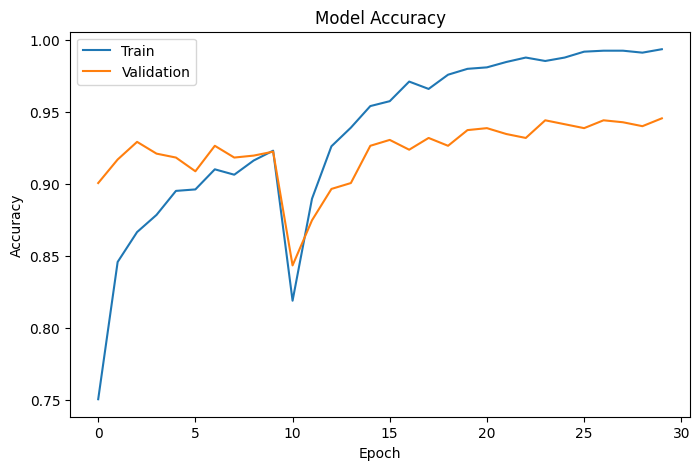

In [21]:
# Combine both phases for the plot
acc = history1.history['accuracy'] + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']

plt.figure(figsize=(8,5))

plt.plot(acc)

plt.plot(val_acc)

plt.title('Model Accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [22]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


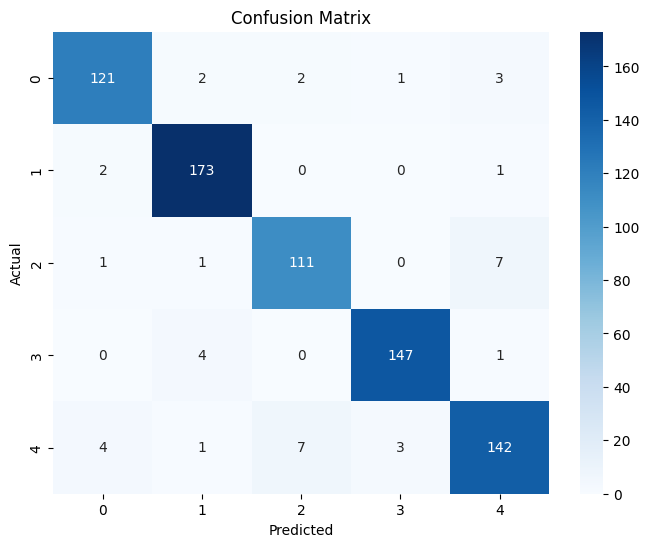

In [23]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [24]:
precision = precision_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("\nPrecision Score:", precision)
print("F1 Score:", f1)


Precision Score: 0.9453760908380746
F1 Score: 0.9453716231163667


In [25]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Classification Report:

              precision    recall  f1-score   support

       daisy       0.95      0.94      0.94       129
   dandelion       0.96      0.98      0.97       176
       roses       0.93      0.93      0.93       120
  sunflowers       0.97      0.97      0.97       152
      tulips       0.92      0.90      0.91       157

    accuracy                           0.95       734
   macro avg       0.94      0.94      0.94       734
weighted avg       0.95      0.95      0.95       734



In [26]:
print(class_names)
print(len(class_names))

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
5
